### Cell 1


In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Cell 2 Paths

In [2]:
def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

TRAINING_RESULTS_DIR = PROJECT_ROOT / "results" / "03_model_training"
EVALUATION_RESULTS_DIR = PROJECT_ROOT / "results" / "04_model_evaluation"
PLOTS_DIR = PROJECT_ROOT / "plots" / "04_model_evaluation"

EVALUATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Training results directory: {TRAINING_RESULTS_DIR}")
print(f"Evaluation results directory: {EVALUATION_RESULTS_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

Project root: /home/iailab42/khans1/projects/xai
Training results directory: /home/iailab42/khans1/projects/xai/results/03_model_training
Evaluation results directory: /home/iailab42/khans1/projects/xai/results/04_model_evaluation
Plots directory: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation


### Cell 3 : Load Prediction Files

In [3]:
model_names = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "mlp"
]


def load_prediction_files(results_dir: Path, model_names: list[str]) -> dict:
    prediction_data = {}

    for model_name in model_names:
        file_path = results_dir / f"{model_name}_predictions.csv"

        if not file_path.exists():
            raise FileNotFoundError(f"Missing prediction file: {file_path}")

        prediction_df = pd.read_csv(file_path)

        required_columns = {"sample_id", "true_label", "predicted_label"}

        if not required_columns.issubset(prediction_df.columns):
            raise ValueError(
                f"{model_name} prediction file is missing required columns. "
                f"Found columns: {list(prediction_df.columns)}"
            )

        prediction_data[model_name] = prediction_df

    return prediction_data


prediction_data = load_prediction_files(TRAINING_RESULTS_DIR, model_names)

for model_name, df in prediction_data.items():
    print(f"{model_name}: {df.shape}")

logistic_regression: (2709, 3)
decision_tree: (2709, 3)
random_forest: (2709, 3)
mlp: (2709, 3)


### Cell 4: Calculate Evaluation Metrics

In [4]:
def calculate_model_metrics(model_name: str, prediction_df: pd.DataFrame) -> dict:
    y_true = prediction_df["true_label"]
    y_pred = prediction_df["predicted_label"]

    return {
        "model_name": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }


metrics = []

for model_name, prediction_df in prediction_data.items():
    metrics.append(calculate_model_metrics(model_name, prediction_df))

metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

metrics_df

,model_name,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,mlp,0.925065,0.935855,0.934572,0.935130,0.925053
1,logistic_regression,0.919158,0.930725,0.930049,0.930237,0.919290
2,random_forest,0.919158,0.931380,0.928934,0.930081,0.919102
3,decision_tree,0.895533,0.909421,0.910429,0.909784,0.895289


### Cell 5: Save Evaluation Metrics

In [5]:
metrics_path = EVALUATION_RESULTS_DIR / "evaluation_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

metrics_json_path = EVALUATION_RESULTS_DIR / "evaluation_metrics.json"

with open(metrics_json_path, "w", encoding="utf-8") as file:
    json.dump(metrics_df.to_dict(orient="records"), file, indent=4)

print(f"Saved CSV: {metrics_path}")
print(f"Saved JSON: {metrics_json_path}")

Saved CSV: /home/iailab42/khans1/projects/xai/results/04_model_evaluation/evaluation_metrics.csv
Saved JSON: /home/iailab42/khans1/projects/xai/results/04_model_evaluation/evaluation_metrics.json


### Cell 6

In [6]:
classification_reports = {}

for model_name, prediction_df in prediction_data.items():

    y_true = prediction_df["true_label"]
    y_pred = prediction_df["predicted_label"]

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    classification_reports[model_name] = report

report_path = EVALUATION_RESULTS_DIR / "classification_reports.json"

with open(report_path, "w") as f:
    json.dump(classification_reports, f, indent=4)

print(f"Saved: {report_path}")

Saved: /home/iailab42/khans1/projects/xai/results/04_model_evaluation/classification_reports.json


### Cell 7 : Find Best Model

In [7]:
best_accuracy_model = metrics_df.loc[
    metrics_df["accuracy"].idxmax(),
    "model_name"
]

best_f1_model = metrics_df.loc[
    metrics_df["f1_macro"].idxmax(),
    "model_name"
]

print(f"Best Accuracy Model : {best_accuracy_model}")
print(f"Best Macro F1 Model : {best_f1_model}")

Best Accuracy Model : mlp
Best Macro F1 Model : mlp


### Cell 8: Confusion Matrices

<Figure size 800x600 with 0 Axes>

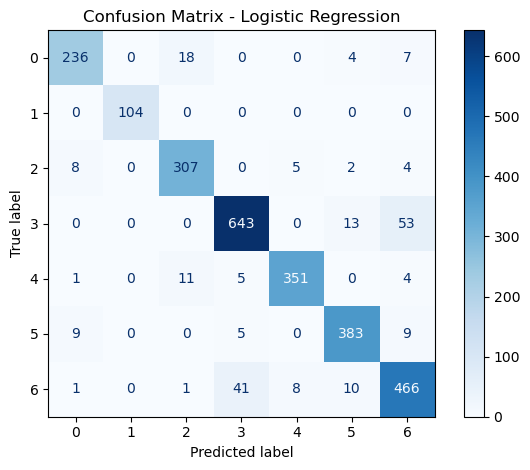

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/confusion_matrix_logistic_regression.png


<Figure size 800x600 with 0 Axes>

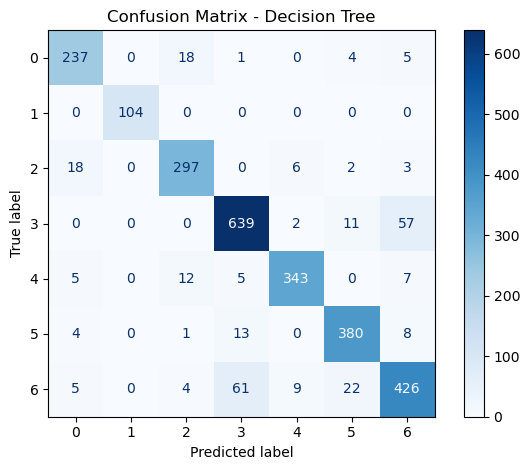

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/confusion_matrix_decision_tree.png


<Figure size 800x600 with 0 Axes>

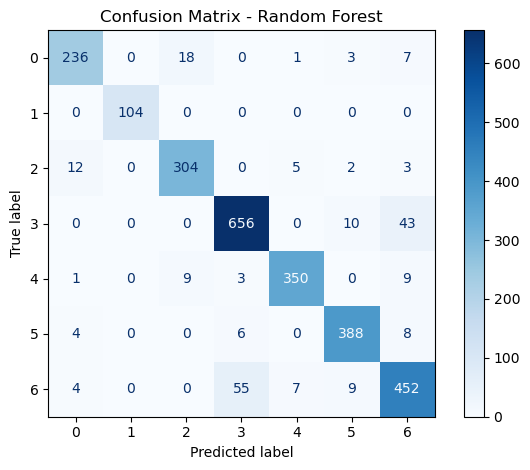

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/confusion_matrix_random_forest.png


<Figure size 800x600 with 0 Axes>

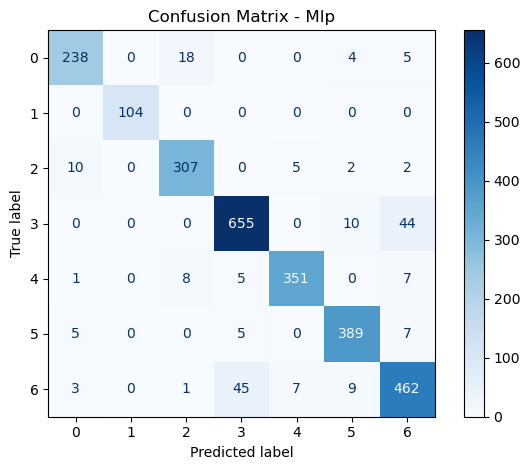

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/confusion_matrix_mlp.png


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrices = {}

for model_name, prediction_df in prediction_data.items():

    y_true = prediction_df["true_label"]
    y_pred = prediction_df["predicted_label"]

    cm = confusion_matrix(y_true, y_pred)

    confusion_matrices[model_name] = cm.tolist()

    plt.figure(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(
        cmap="Blues",
        values_format="d"
    )

    plt.title(
        f"Confusion Matrix - {model_name.replace('_', ' ').title()}"
    )

    plt.tight_layout()

    plot_path = (
        PLOTS_DIR /
        f"confusion_matrix_{model_name}.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {plot_path}")

In [9]:
confusion_matrix_path = (
    EVALUATION_RESULTS_DIR /
    "confusion_matrices.json"
)

with open(confusion_matrix_path, "w") as f:
    json.dump(
        confusion_matrices,
        f,
        indent=4
    )

print(
    f"Saved: {confusion_matrix_path}"
)

Saved: /home/iailab42/khans1/projects/xai/results/04_model_evaluation/confusion_matrices.json


### Cell 9: Accuracy Comparison Plot

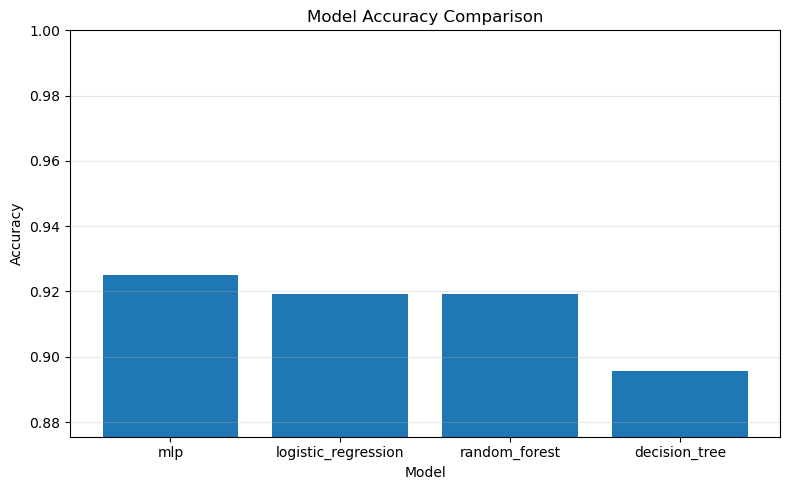

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/accuracy_comparison.png


In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    metrics_df["model_name"],
    metrics_df["accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(
    min(metrics_df["accuracy"]) - 0.02,
    1.0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plot_path = (
    PLOTS_DIR /
    "accuracy_comparison.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot_path}")

### Cell 10: Macro F1 Comparison Plot

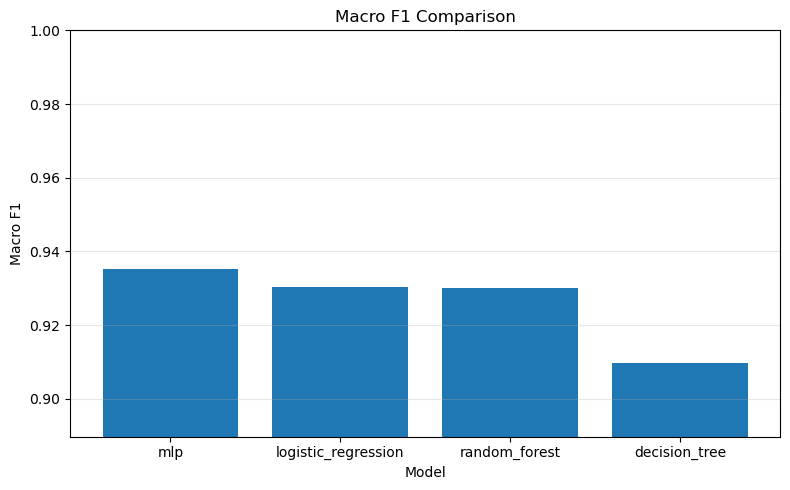

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/macro_f1_comparison.png


In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    metrics_df["model_name"],
    metrics_df["f1_macro"]
)

plt.title("Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1")

plt.ylim(
    min(metrics_df["f1_macro"]) - 0.02,
    1.0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plot_path = (
    PLOTS_DIR /
    "macro_f1_comparison.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot_path}")

In [12]:
class_names = [
    "BARBUNYA",
    "BOMBAY",
    "CALI",
    "DERMASON",
    "HOROZ",
    "SEKER",
    "SIRA"
]

class_id_to_name = {
    class_id: class_name
    for class_id, class_name in enumerate(class_names)
}

class_id_to_name

{0: 'BARBUNYA',
 1: 'BOMBAY',
 2: 'CALI',
 3: 'DERMASON',
 4: 'HOROZ',
 5: 'SEKER',
 6: 'SIRA'}

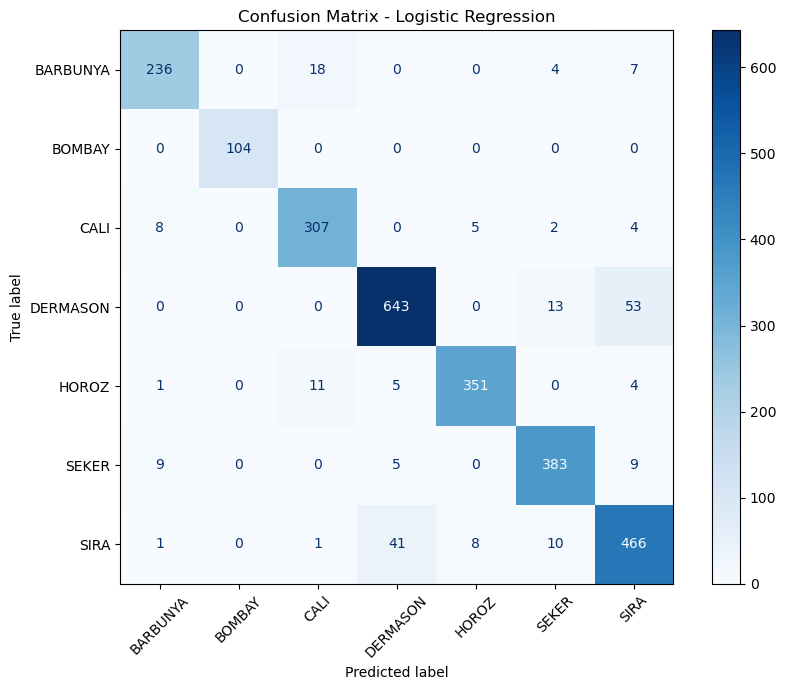

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/confusion_matrix_named_logistic_regression.png


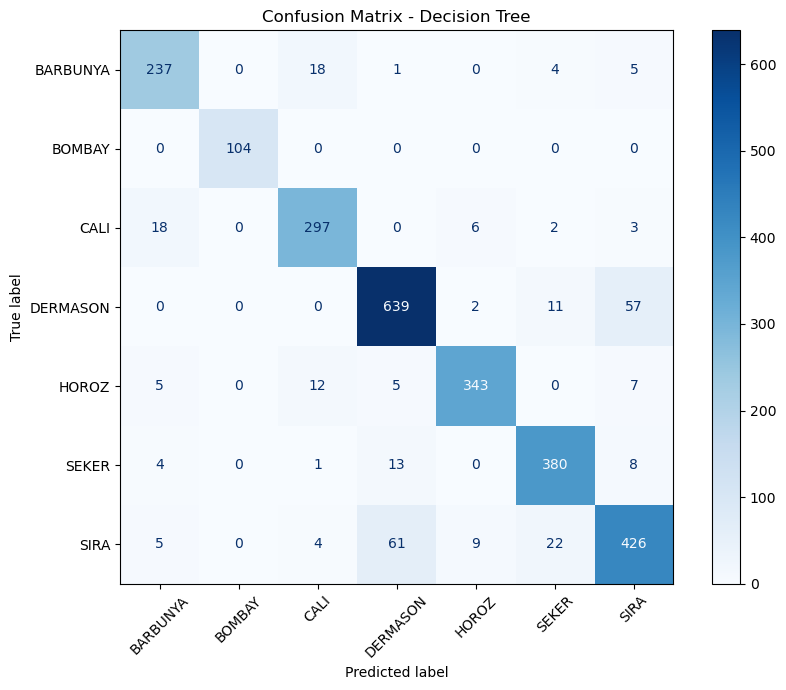

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/confusion_matrix_named_decision_tree.png


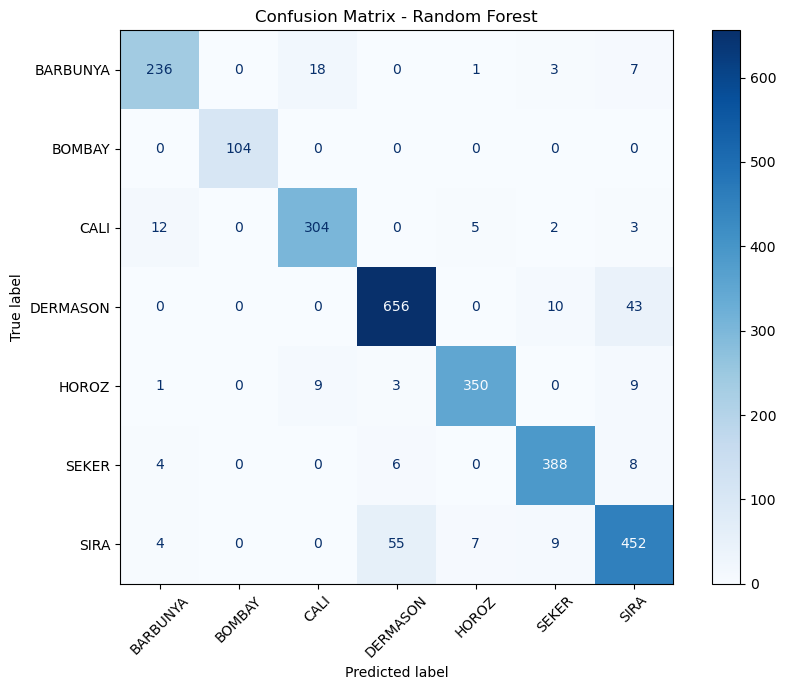

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/confusion_matrix_named_random_forest.png


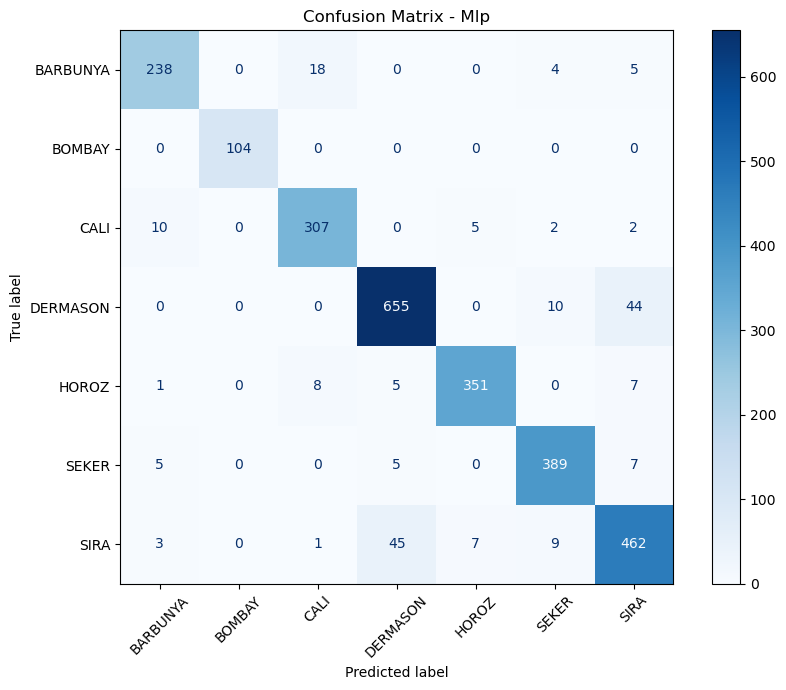

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/confusion_matrix_named_mlp.png


In [13]:
for model_name, prediction_df in prediction_data.items():

    y_true = prediction_df["true_label"]
    y_pred = prediction_df["predicted_label"]

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(9, 7))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        xticks_rotation=45
    )

    ax.set_title(
        f"Confusion Matrix - {model_name.replace('_', ' ').title()}"
    )

    plt.tight_layout()

    plot_path = PLOTS_DIR / f"confusion_matrix_named_{model_name}.png"

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {plot_path}")

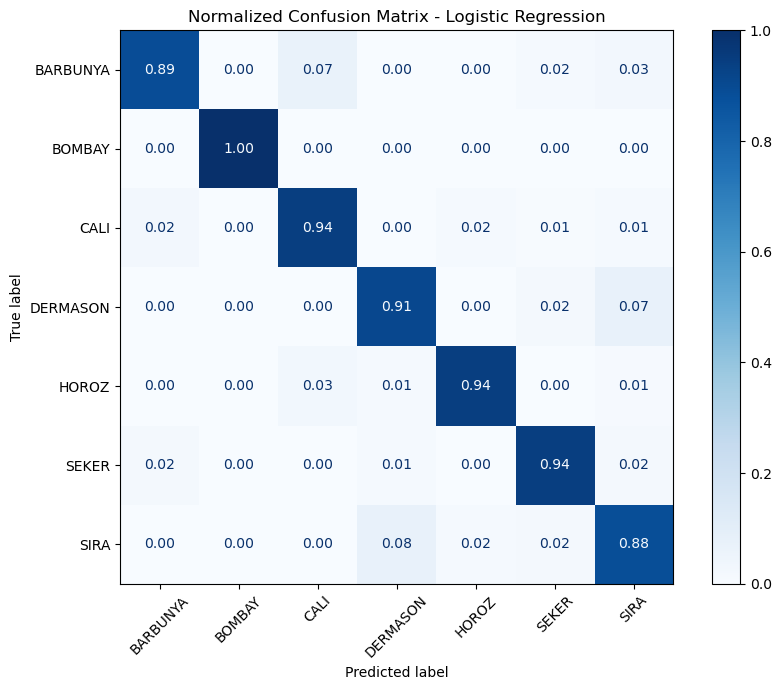

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/normalized_confusion_matrix_logistic_regression.png


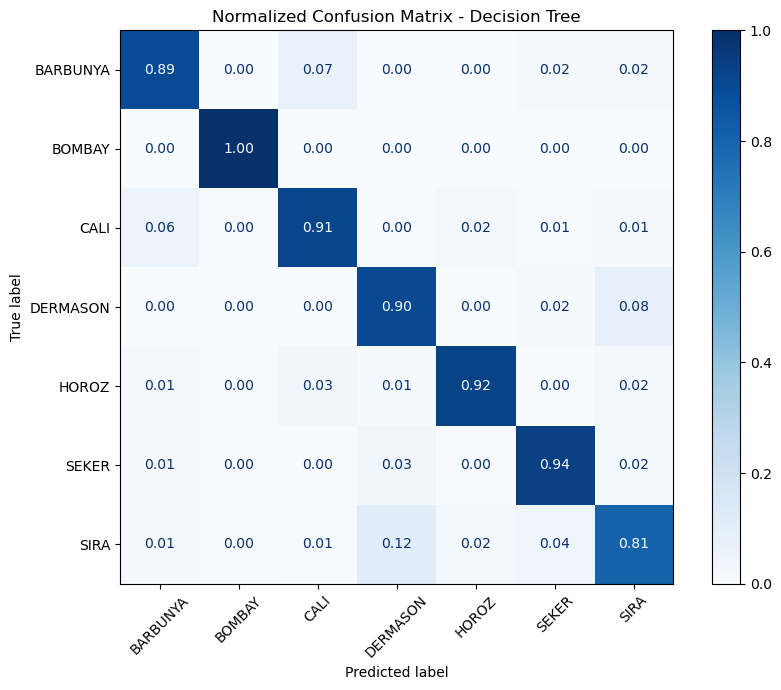

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/normalized_confusion_matrix_decision_tree.png


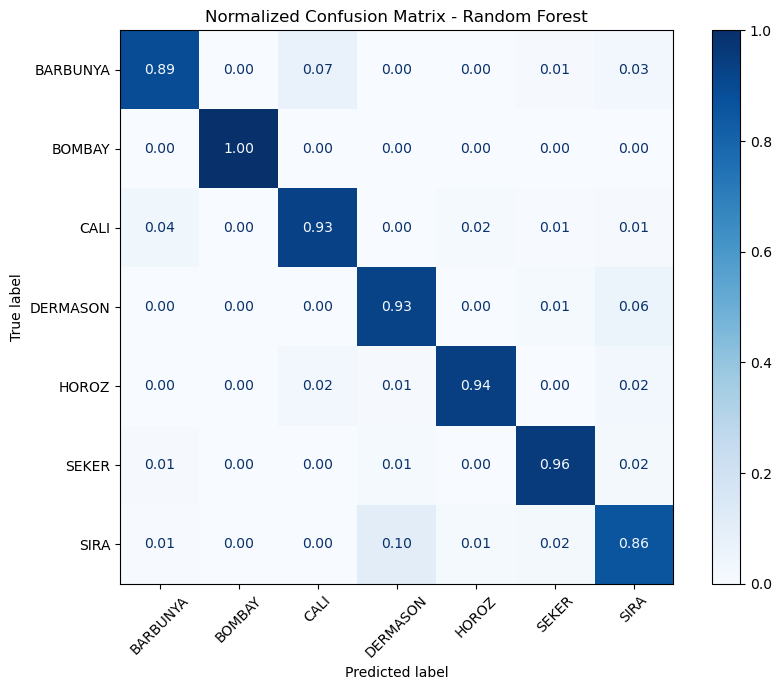

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/normalized_confusion_matrix_random_forest.png


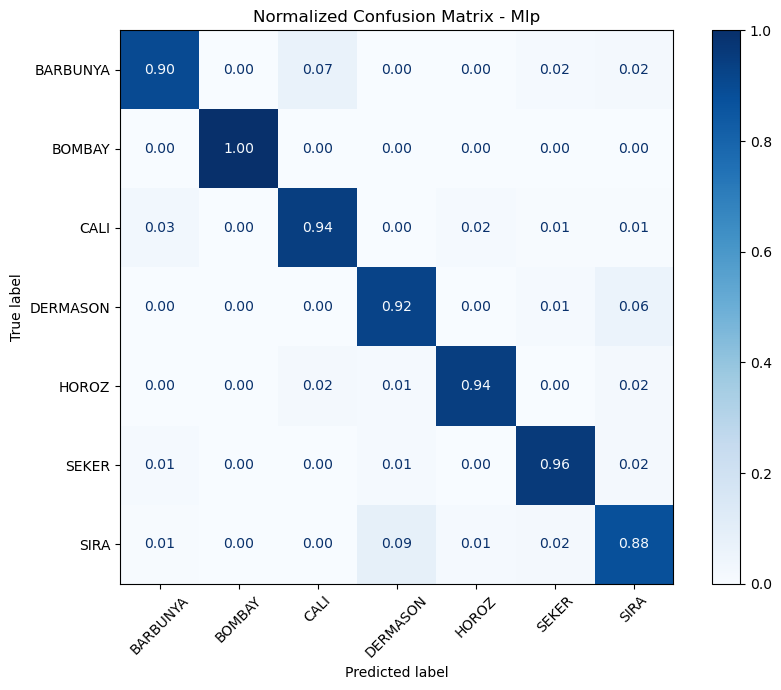

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/normalized_confusion_matrix_mlp.png


In [14]:
for model_name, prediction_df in prediction_data.items():

    y_true = prediction_df["true_label"]
    y_pred = prediction_df["predicted_label"]

    cm_normalized = confusion_matrix(
        y_true,
        y_pred,
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f",
        ax=ax,
        xticks_rotation=45
    )

    ax.set_title(
        f"Normalized Confusion Matrix - {model_name.replace('_', ' ').title()}"
    )

    plt.tight_layout()

    plot_path = PLOTS_DIR / f"normalized_confusion_matrix_{model_name}.png"

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {plot_path}")

In [15]:
classwise_rows = []

for model_name, prediction_df in prediction_data.items():

    y_true = prediction_df["true_label"]
    y_pred = prediction_df["predicted_label"]

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    for class_id, class_name in class_id_to_name.items():

        class_report = report[str(class_id)]

        classwise_rows.append({
            "model_name": model_name,
            "class_id": class_id,
            "class_name": class_name,
            "precision": class_report["precision"],
            "recall": class_report["recall"],
            "f1_score": class_report["f1-score"],
            "support": class_report["support"]
        })

classwise_df = pd.DataFrame(classwise_rows)

classwise_path = EVALUATION_RESULTS_DIR / "classwise_performance.csv"
classwise_df.to_csv(classwise_path, index=False)

print(f"Saved: {classwise_path}")

classwise_df

Saved: /home/iailab42/khans1/projects/xai/results/04_model_evaluation/classwise_performance.csv


,model_name,class_id,class_name,precision,recall,f1_score,support
0,logistic_regression,0,BARBUNYA,0.925490,0.890566,0.907692,265.0
1,logistic_regression,1,BOMBAY,1.000000,1.000000,1.000000,104.0
2,logistic_regression,2,CALI,0.910979,0.941718,0.926094,326.0
3,logistic_regression,3,DERMASON,0.926513,0.906911,0.916607,709.0
4,logistic_regression,4,HOROZ,0.964286,0.943548,0.953804,372.0
5,logistic_regression,5,SEKER,0.929612,0.943350,0.936430,406.0
6,logistic_regression,6,SIRA,0.858195,0.884250,0.871028,527.0
7,decision_tree,0,BARBUNYA,0.881041,0.894340,0.887640,265.0
8,decision_tree,1,BOMBAY,1.000000,1.000000,1.000000,104.0
9,decision_tree,2,CALI,0.894578,0.911043,0.902736,326.0


In [16]:
confusion_pair_rows = []

for model_name, prediction_df in prediction_data.items():

    y_true = prediction_df["true_label"]
    y_pred = prediction_df["predicted_label"]

    cm = confusion_matrix(y_true, y_pred)

    for true_class_id in range(len(class_names)):
        for predicted_class_id in range(len(class_names)):

            if true_class_id == predicted_class_id:
                continue

            count = cm[true_class_id, predicted_class_id]

            if count > 0:
                confusion_pair_rows.append({
                    "model_name": model_name,
                    "true_class_id": true_class_id,
                    "true_class_name": class_id_to_name[true_class_id],
                    "predicted_class_id": predicted_class_id,
                    "predicted_class_name": class_id_to_name[predicted_class_id],
                    "confusion_count": int(count)
                })

confusion_pairs_df = pd.DataFrame(confusion_pair_rows)

confusion_pairs_df = confusion_pairs_df.sort_values(
    by="confusion_count",
    ascending=False
).reset_index(drop=True)

confusion_pairs_path = EVALUATION_RESULTS_DIR / "top_confusion_pairs.csv"
confusion_pairs_df.to_csv(confusion_pairs_path, index=False)

print(f"Saved: {confusion_pairs_path}")

confusion_pairs_df.head(20)

Saved: /home/iailab42/khans1/projects/xai/results/04_model_evaluation/top_confusion_pairs.csv


,model_name,true_class_id,true_class_name,predicted_class_id,predicted_class_name,confusion_count
0,decision_tree,6,SIRA,3,DERMASON,61
1,decision_tree,3,DERMASON,6,SIRA,57
2,random_forest,6,SIRA,3,DERMASON,55
3,logistic_regression,3,DERMASON,6,SIRA,53
4,mlp,6,SIRA,3,DERMASON,45
5,mlp,3,DERMASON,6,SIRA,44
6,random_forest,3,DERMASON,6,SIRA,43
7,logistic_regression,6,SIRA,3,DERMASON,41
8,decision_tree,6,SIRA,5,SEKER,22
9,random_forest,0,BARBUNYA,2,CALI,18


In [17]:
evaluation_summary = {
    "best_accuracy_model": best_accuracy_model,
    "best_macro_f1_model": best_f1_model,
    "main_findings": {
        "best_overall_model": "MLP achieved the highest accuracy and macro F1-score.",
        "strong_reference_models": "Logistic Regression and Random Forest performed very close to MLP.",
        "weakest_model": "Decision Tree had the lowest overall performance.",
        "easiest_class": "BOMBAY was classified perfectly by all models.",
        "hardest_confusion_pair": "DERMASON and SIRA were the most frequently confused classes.",
        "secondary_confusion_pair": "BARBUNYA and CALI also showed repeated confusion."
    }
}

evaluation_summary_path = EVALUATION_RESULTS_DIR / "evaluation_summary.json"

with open(evaluation_summary_path, "w", encoding="utf-8") as file:
    json.dump(evaluation_summary, file, indent=4)

print(f"Saved: {evaluation_summary_path}")

Saved: /home/iailab42/khans1/projects/xai/results/04_model_evaluation/evaluation_summary.json


### Heatmap classwise

In [18]:
evaluation_summary = {
    "best_accuracy_model": best_accuracy_model,
    "best_macro_f1_model": best_f1_model,
    "main_findings": {
        "best_overall_model": "MLP achieved the highest accuracy and macro F1-score.",
        "strong_reference_models": "Logistic Regression and Random Forest performed very close to MLP.",
        "weakest_model": "Decision Tree had the lowest overall performance.",
        "easiest_class": "BOMBAY was classified perfectly by all models.",
        "hardest_confusion_pair": "DERMASON and SIRA were the most frequently confused classes.",
        "secondary_confusion_pair": "BARBUNYA and CALI also showed repeated confusion."
    }
}

evaluation_summary_path = EVALUATION_RESULTS_DIR / "evaluation_summary.json"

with open(evaluation_summary_path, "w", encoding="utf-8") as file:
    json.dump(evaluation_summary, file, indent=4)

print(f"Saved: {evaluation_summary_path}")

Saved: /home/iailab42/khans1/projects/xai/results/04_model_evaluation/evaluation_summary.json


### Top Confusion Pair plot

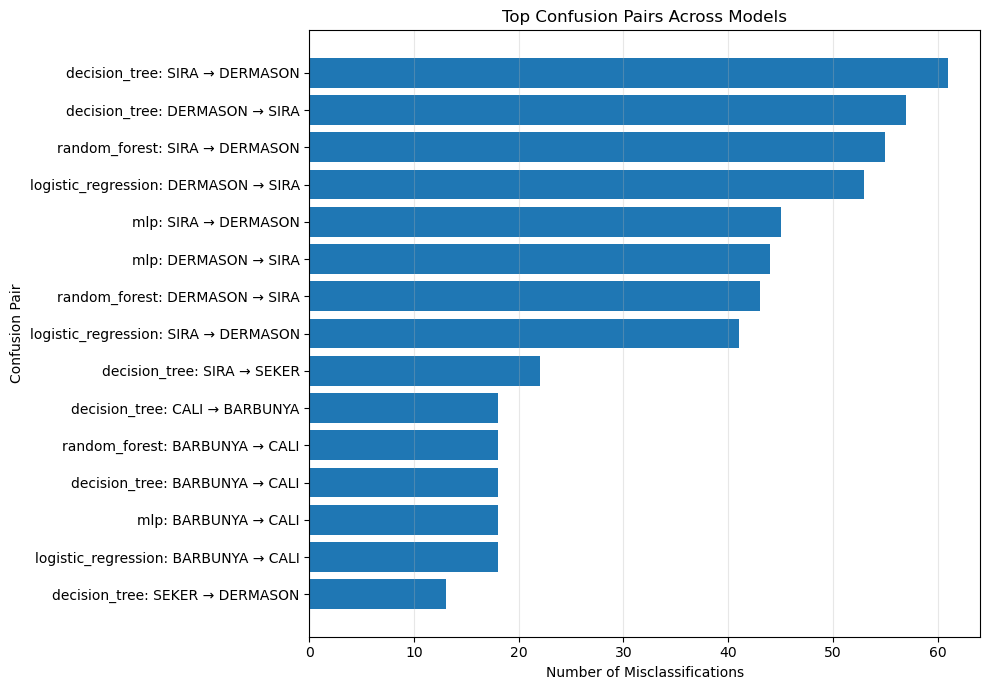

Saved: /home/iailab42/khans1/projects/xai/plots/04_model_evaluation/top_confusion_pairs.png


In [19]:
top_n = 15

top_confusions = confusion_pairs_df.head(top_n).copy()

top_confusions["confusion_label"] = (
    top_confusions["model_name"]
    + ": "
    + top_confusions["true_class_name"]
    + " → "
    + top_confusions["predicted_class_name"]
)

top_confusions = top_confusions.sort_values(
    by="confusion_count",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_confusions["confusion_label"],
    top_confusions["confusion_count"]
)

plt.title("Top Confusion Pairs Across Models")
plt.xlabel("Number of Misclassifications")
plt.ylabel("Confusion Pair")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plot_path = PLOTS_DIR / "top_confusion_pairs.png"

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot_path}")